# TOPIC MODELING - LDA (Latent Dirichlet Allocation)

**Input**: Hasil analisis sentimen (13.192 data, no-stem, SLA + Ignore Function)  
**Target**: Data sentimen negatif  
**Metode**: LDA via Gensim  

**Referensi utama**:
- Gensim LDA: https://radimrehurek.com/gensim/models/ldamodel.html
- Gensim Dictionary & Corpus: https://radimrehurek.com/gensim/corpora/dictionary.html
- CoherenceModel (C_v): Röder et al. (2015) https://github.com/dice-group/Palmetto
- pyLDAvis: Sievert & Shirley (2014) https://github.com/bmabey/pyLDAvis
- Contoh pipeline LDA dengan Gensim: https://github.com/RaRe-Technologies/gensim/blob/develop/docs/notebooks/lda_training_tips.ipynb

In [19]:
# 1. Instalasi Library

import sys
import subprocess
import importlib

required_packages = [
    'gensim',
    'pyLDAvis',
    'nltk'
]

for package in required_packages:

    try:
        importlib.import_module(package)
        print(f"{package} sudah terinstall")

    except ImportError:

        print(f"Menginstall {package}...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package
        ])

        print(f"{package} berhasil diinstall")

gensim sudah terinstall
pyLDAvis sudah terinstall
nltk sudah terinstall


In [2]:
# 2. Import Library

import os
import warnings
import logging

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import gensim
from gensim import corpora

from gensim.models import (
    LdaModel,
    CoherenceModel
)

from gensim.models.phrases import (
    Phrases,
    Phraser
)

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [3]:
# 3. Konfigurasi Awal

warnings.filterwarnings('ignore')

logging.disable(logging.CRITICAL)

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

RANDOM_STATE = 42

In [6]:
# 4. Data Loading dan Filtering
print("Memuat data sentimen...")

file_path = '../sentiment-analysis-final/outputs/sentiment_clean.csv'

df = pd.read_csv(file_path)

# Cek kolom yang tersedia
print(f"Kolom tersedia: {df.columns.tolist()}")

df_neg = (
    df[df['sentiment'] == 'negative']
    .copy()
    .reset_index(drop=True)
)

# Memastikan compound_score ada dan bertipe float
if 'compound_score' in df_neg.columns:
    df_neg['compound_score'] = pd.to_numeric(df_neg['compound_score'], errors='coerce')
    print(f"Range compound_score: {df_neg['compound_score'].min():.4f} s/d {df_neg['compound_score'].max():.4f}")

print(f"Total data sentimen negatif: {len(df_neg)}")

Memuat data sentimen...
Kolom tersedia: ['no', 'timestamp', 'teks', 'teks_processed', 'sentiment', 'compound_score']
Range compound_score: -0.9926 s/d -0.0516
Total data sentimen negatif: 4854


In [7]:
# 5. Preprocessing untuk LDA

print("Melakukan preprocessing teks...")

stop_words = set(stopwords.words('indonesian'))

custom_stopwords = {
    'rt', 'via', 'twitter', 'tweet', 'x',
    'dpr', 'ri', 'dprri', 'dpri',
    'anggota', 'rapat', 'paripurna',
    'ruu', 'uu',
    'pak', 'bu',
    'gan', 'sis', 'min',
    'nya', 'aja', 'nih',
    'lah', 'kah', 'kan'
}

stop_words.update(custom_stopwords)

def preprocess_for_lda(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    tokens = word_tokenize(text)

    tokens = [
        token for token in tokens
        if token.isalpha()
        and token not in stop_words
        and len(token) > 2
    ]

    return tokens

df_neg['tokens_lda'] = df_neg['teks_processed'].apply(
    preprocess_for_lda
)

df_neg_filtered = df_neg[df_neg['tokens_lda'].apply(len) >= 5].copy().reset_index(drop=True)

print(f"Total data sebelum document filtering : {len(df_neg)}")
print(f"Total data setelah document filtering  : {len(df_neg_filtered)}")

df_neg_filtered['teks_lda_clean'] = df_neg_filtered['tokens_lda'].apply(lambda x: ' '.join(x))

df_neg_filtered.to_csv('lda_preprocessing_clean.csv', index=False, encoding='utf-8')

print("\n[SUKSES] Berkas lda_preprocessing_clean.csv berhasil disimpan")

Melakukan preprocessing teks...
Total data sebelum document filtering : 4854
Total data setelah document filtering  : 4378

[SUKSES] Berkas lda_preprocessing_clean.csv berhasil disimpan


Data `teks_processed` sudah melalui noise removal, word lengthening normalization, slang normalization, dan tokenisasi di tahap sebelumnya.

Preprocessing tambahan di sini hanya untuk kebutuhan teknis LDA:
- **Stopword removal**: kata fungsi tidak membawa informasi topik dan akan mendominasi distribusi kata secara artifisial
- **Filter panjang token**: buang token ≤ 5 karakter (sisa noise atau sufiks)
- **Lowercase**: agar variasi kapitalisasi dihitung sebagai kata yang sama

Referensi penerapan filter ini: https://radimrehurek.com/gensim/corpora/dictionary.html#gensim.corpora.dictionary.Dictionary.filter_extremes

In [8]:
# 6. Bigram dan Trigram

from gensim.models import Phrases
from gensim.models.phrases import Phraser

print("Membangun bigram dan trigram...")

# Membuat model bigram
bigram = Phrases(
    df_neg['tokens_lda'],
    min_count=5,
    threshold=10
)

# Membuat model trigram
trigram = Phrases(
    bigram[df_neg['tokens_lda']],
    threshold=10
)

# Efisiensi model phrase
bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

# Fungsi pembentukan bigram
def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

# Fungsi pembentukan trigram
def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

# Terapkan bigram dan trigram
df_neg['tokens_lda'] = make_trigrams(
    make_bigrams(df_neg['tokens_lda'])
)

print("Bigram dan trigram berhasil dibuat")
print(df_neg['tokens_lda'].head())

2026-06-01 21:42:33,335 : INFO : collecting all words and their counts
2026-06-01 21:42:33,336 : INFO : PROGRESS: at sentence #0, processed 0 words and 0 word types
2026-06-01 21:42:33,378 : INFO : collected 43019 token types (unigram + bigrams) from a corpus of 51146 words and 4854 sentences
2026-06-01 21:42:33,378 : INFO : merged Phrases<43019 vocab, min_count=5, threshold=10, max_vocab_size=40000000>
2026-06-01 21:42:33,378 : INFO : Phrases lifecycle event {'msg': 'built Phrases<43019 vocab, min_count=5, threshold=10, max_vocab_size=40000000> in 0.04s', 'datetime': '2026-06-01T21:42:33.378202', 'gensim': '4.4.0', 'python': '3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-06-01 21:42:33,382 : INFO : collecting all words and their counts
2026-06-01 21:42:33,382 : INFO : PROGRESS: at sentence #0, processed 0 words and 0 word types
2026-06-01 21:42:33,479 : INFO : collected 43841 token t

Membangun bigram dan trigram...


2026-06-01 21:42:33,528 : INFO : FrozenPhrases lifecycle event {'msg': 'exported FrozenPhrases<394 phrases, min_count=5, threshold=10> from Phrases<43019 vocab, min_count=5, threshold=10, max_vocab_size=40000000> in 0.05s', 'datetime': '2026-06-01T21:42:33.528002', 'gensim': '4.4.0', 'python': '3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-06-01 21:42:33,529 : INFO : exporting phrases from Phrases<43841 vocab, min_count=5, threshold=10, max_vocab_size=40000000>
2026-06-01 21:42:33,575 : INFO : FrozenPhrases lifecycle event {'msg': 'exported FrozenPhrases<392 phrases, min_count=5, threshold=10> from Phrases<43841 vocab, min_count=5, threshold=10, max_vocab_size=40000000> in 0.05s', 'datetime': '2026-06-01T21:42:33.575418', 'gensim': '4.4.0', 'python': '3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'c

Bigram dan trigram berhasil dibuat
0    [tertibkan, media, online, pemerintah, sporadi...
1    [dievaluasi, kebijakan_bebas_visa, negara, tio...
2             [ngambang, aturan, logis, undang_undang]
3    [kebebasan, bersuara, berpendapat, dijamin, ke...
4    [komisi, okky, asokawati, evaluasi, moratorium...
Name: tokens_lda, dtype: object


In [9]:
# 7. Dictionary & Corpus

print("Membangun dictionary dan corpus...")

dictionary = corpora.Dictionary(
    df_neg['tokens_lda']
)

dictionary.filter_extremes(
    no_below=5,
    no_above=0.5
)

corpus = [
    dictionary.doc2bow(text)
    for text in df_neg['tokens_lda']
]

print(f"Jumlah vocabulary: {len(dictionary)}")
print(f"Jumlah corpus: {len(corpus)}")

2026-06-01 21:42:36,223 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-06-01 21:42:36,265 : INFO : built Dictionary<10884 unique tokens: ['berseberangan', 'media', 'online', 'pemerintah', 'selektif']...> from 4854 documents (total 44256 corpus positions)
2026-06-01 21:42:36,266 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<10884 unique tokens: ['berseberangan', 'media', 'online', 'pemerintah', 'selektif']...> from 4854 documents (total 44256 corpus positions)", 'datetime': '2026-06-01T21:42:36.266185', 'gensim': '4.4.0', 'python': '3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-06-01 21:42:36,271 : INFO : discarding 8998 tokens: [('berseberangan', 3), ('selektif', 3), ('sporadis', 1), ('tertibkan', 1), ('martabat', 1), ('tersembunyi', 2), ('logis', 3), ('ngambang', 1), ('berpendapat', 4), ('kebablasan', 2)]...
2026-06-01 21:42:36,272 : INFO : keepin

Membangun dictionary dan corpus...
Jumlah vocabulary: 1886
Jumlah corpus: 4854


Referensi: https://radimrehurek.com/gensim/corpora/dictionary.html

`filter_extremes`: menghapus kata yang terlalu jarang (`no_below`) atau terlalu umum (`no_above`) agar tidak mendominasi topik secara statistik.

In [ ]:
# 8. Optimasi Jumlah Topik

print("Mencari jumlah topik terbaik...")

k_values = [2, 3, 4, 5, 6, 7]

coherence_scores = []

for k in k_values:

    print(f"\nTraining LDA dengan k={k}")

    lda_temp = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=RANDOM_STATE,
        passes=5,
        iterations=50,
        alpha='auto',
        eta='auto'
    )

    coherence_model = CoherenceModel(
        model=lda_temp,
        texts=df_neg['tokens_lda'],
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()

    coherence_scores.append(coherence)

    print(f"Coherence Score: {coherence:.4f}")

best_k = k_values[np.argmax(coherence_scores)]

print(f"\nJumlah topik terbaik: {best_k}")
print(f"Best coherence score: {max(coherence_scores):.4f}")

coherence_df = pd.DataFrame({
    'jumlah_topik': k_values,
    'coherence_score': coherence_scores
})

coherence_df.to_csv(
    'lda_coherence_scores.csv',
    index=False
)

print("Coherence score berhasil disimpan")

2026-06-01 21:43:22,930 : INFO : using autotuned alpha, starting with [np.float32(0.5), np.float32(0.5)]
2026-06-01 21:43:22,931 : INFO : using serial LDA version on this node
2026-06-01 21:43:22,931 : INFO : running online (multi-pass) LDA training, 2 topics, 5 passes over the supplied corpus of 4854 documents, updating model once every 2000 documents, evaluating perplexity every 4854 documents, iterating 50x with a convergence threshold of 0.001000
2026-06-01 21:43:22,941 : INFO : PROGRESS: pass 0, at document #2000/4854


Mencari jumlah topik terbaik...

Training LDA dengan k=2


2026-06-01 21:43:23,520 : INFO : optimized alpha [np.float32(0.6754342), np.float32(0.72091895)]
2026-06-01 21:43:23,520 : INFO : merging changes from 2000 documents into a model of 4854 documents
2026-06-01 21:43:23,520 : INFO : topic #0 (0.675): 0.018*"kebijakan" + 0.015*"reses" + 0.012*"pembahasan" + 0.008*"pemerintah" + 0.008*"undang_undang" + 0.008*"komisi" + 0.007*"wakil_rakyat" + 0.007*"dewan_perwakilan_rakyat" + 0.006*"rakyat" + 0.006*"terkait"
2026-06-01 21:43:23,527 : INFO : topic #1 (0.721): 0.027*"kebijakan" + 0.023*"wakil_rakyat" + 0.016*"komisi" + 0.016*"rakyat" + 0.015*"undang_undang" + 0.013*"reses" + 0.008*"salah" + 0.007*"terkait" + 0.007*"pengesahan" + 0.007*"disahkan"
2026-06-01 21:43:23,527 : INFO : topic diff=1.266914, rho=1.000000
2026-06-01 21:43:23,530 : INFO : PROGRESS: pass 0, at document #4000/4854
2026-06-01 21:43:23,844 : INFO : optimized alpha [np.float32(0.7894615), np.float32(0.9260051)]
2026-06-01 21:43:23,845 : INFO : merging changes from 2000 documen

Menggunakan metrik **C_v coherence** yang direkomendasikan oleh Röder et al. (2015) sebagai metrik evaluasi kualitas topik yang paling berkorelasi dengan penilaian manusia.

**Coherence score** adalah metrik evaluasi dalam topic modeling (seperti algoritma LDA) yang digunakan untuk mengukur tingkat konsistensi dan interpretabilitas sebuah topi

Referensi:
- Röder et al. (2015): http://svn.aksw.org/papers/2015/WSDM_Topic_Evaluation/public.pdf
- CoherenceModel Gensim: https://radimrehurek.com/gensim/models/coherencemodel.html
- Contoh grid search: https://github.com/RaRe-Technologies/gensim/blob/develop/docs/notebooks/lda_training_tips.ipynb

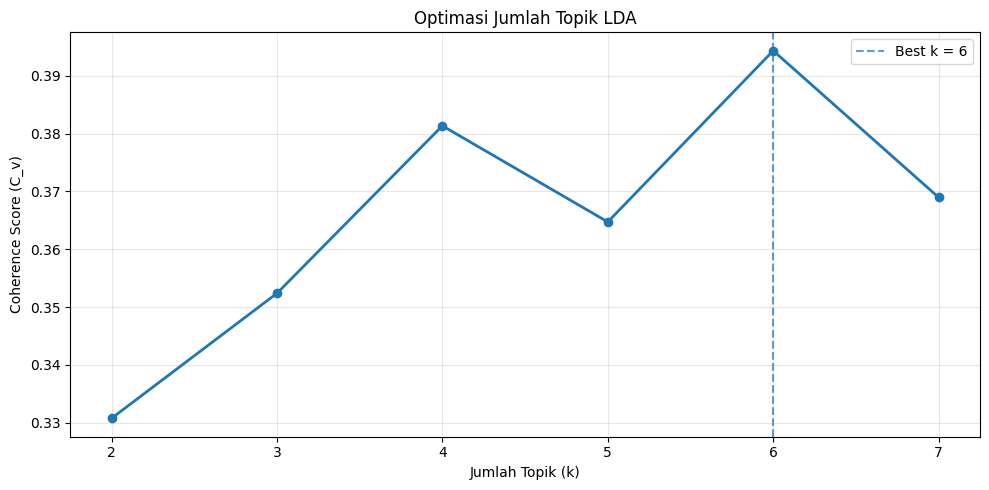

In [ ]:
# 9. Visualisasi Coherence Score

plt.figure(figsize=(10, 5))

plt.plot(
    k_values,
    coherence_scores,
    marker='o',
    linewidth=2
)

plt.axvline(
    x=best_k,
    linestyle='--',
    alpha=0.7,
    label=f'Best k = {best_k}'
)

plt.xlabel('Jumlah Topik (k)')
plt.ylabel('Coherence Score (C_v)')
plt.title('Optimasi Jumlah Topik LDA')

plt.xticks(k_values)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    'lda_coherence_optimization.png',
    dpi=300
)

plt.show()

In [10]:
# 10. Stabilitas Topik per Pass

print("Melihat stabilitas topik tiap pass...")

stability_data = []

for pass_num in range(1, 6):

    lda_pass = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=best_k,
        random_state=RANDOM_STATE,
        passes=pass_num,
        iterations=100,
        alpha='auto',
        eta='auto'
    )

    print(f"\nPass ke-{pass_num}")

    for idx in range(best_k):

        words = lda_pass.show_topic(
            idx,
            topn=10
        )

        word_list = [
            word for word, prob in words
        ]

        joined_words = ", ".join(word_list)

        print(f"Topik {idx + 1}: {joined_words}")

        stability_data.append({
            'pass': pass_num,
            'topic': idx + 1,
            'keywords': joined_words
        })

stability_df = pd.DataFrame(stability_data)

stability_df.to_csv(
    'lda_topic_stability.csv',
    index=False
)

print("\nFile stabilitas berhasil disimpan")

Melihat stabilitas topik tiap pass...

Pass ke-1
Topik 1: kebijakan, ppn, komisi, rakyat, jabatan, terkait, pemerintah, sih, perampasan_aset, pks
Topik 2: kebijakan, rakyat, wakil_rakyat, masyarakat, negara, undang_undang, mkd, prabowo, ppn, korupsi
Topik 3: wakil_rakyat, rakyat, kebijakan, pemerintah, menolak, parpol, setuju, the, undang_undang, reses
Topik 4: reses, orang, indonesia, wakil_rakyat, komisi, aneh, undang_undang, gedung, polri, koruptor
Topik 5: wakil_rakyat, rakyat, aspirasi_rakyat, kebijakan, pemerintah, daerah, komisi, dewan_perwakilan_rakyat, partai, parlemen
Topik 6: kebijakan, rakyat, koruptor, presiden, undang_undang, wakil_rakyat, negara, seumur_hidup, bikin, gara

Pass ke-2
Topik 1: kebijakan, komisi, ppn, terkait, jabatan, pemerintah, pks, jakarta, ruang, rakyat
Topik 2: kebijakan, rakyat, wakil_rakyat, negara, masyarakat, undang_undang, ppn, mkd, prabowo, korupsi
Topik 3: wakil_rakyat, rakyat, menolak, kebijakan, pemerintah, partai, undang_undang, presiden, pa

In [10]:
# 11. Analisis Stabilitas Topik

print("Menganalisis stabilitas topik...")

logging.disable(logging.NOTSET)

logging.basicConfig(
    format='%(asctime)s : %(levelname)s : %(message)s',
    level=logging.INFO
)

stability_data = []

for pass_num in range(1, 6):

    print(f"\nTraining dengan pass={pass_num}")

    lda_pass = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=best_k,
        random_state=RANDOM_STATE,
        passes=pass_num,
        iterations=100,
        alpha='auto',
        eta='auto'
    )

    for idx in range(best_k):

        words = lda_pass.show_topic(
            idx,
            topn=10
        )

        word_list = [
            word for word, prob in words
        ]

        joined_words = ", ".join(word_list)

        print(f"Topik {idx + 1}: {joined_words}")

        stability_data.append({
            'pass': pass_num,
            'topic': idx + 1,
            'keywords': joined_words
        })

stability_df = pd.DataFrame(stability_data)

stability_df.to_csv(
    'lda_topic_stability.csv',
    index=False
)

print("\nStabilitas topik berhasil disimpan")

Menganalisis stabilitas topik...

Training dengan pass=1


NameError: name 'best_k' is not defined

In [12]:
# 12. Training Model Final

print("Training model final...")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    random_state=RANDOM_STATE,
    passes=15,
    iterations=100,
    alpha='auto',
    eta='auto'
)

log_perplexity = lda_model.log_perplexity(
    corpus
)

print(f"Log Perplexity : {log_perplexity:.4f}")

2026-05-19 13:07:50,215 : INFO : using autotuned alpha, starting with [np.float32(0.16666667), np.float32(0.16666667), np.float32(0.16666667), np.float32(0.16666667), np.float32(0.16666667), np.float32(0.16666667)]
2026-05-19 13:07:50,216 : INFO : using serial LDA version on this node
2026-05-19 13:07:50,217 : INFO : running online (multi-pass) LDA training, 6 topics, 15 passes over the supplied corpus of 4378 documents, updating model once every 2000 documents, evaluating perplexity every 4378 documents, iterating 100x with a convergence threshold of 0.001000
2026-05-19 13:07:50,219 : INFO : PROGRESS: pass 0, at document #2000/4378


Training model final...


2026-05-19 13:07:50,605 : INFO : optimized alpha [np.float32(0.1312502), np.float32(0.14084752), np.float32(0.13614656), np.float32(0.13990952), np.float32(0.13431963), np.float32(0.12819828)]
2026-05-19 13:07:50,612 : INFO : merging changes from 2000 documents into a model of 4378 documents
2026-05-19 13:07:50,613 : INFO : topic #5 (0.128): 0.031*"kebijakan" + 0.021*"rakyat" + 0.021*"undang_undang" + 0.017*"komisi" + 0.014*"salah" + 0.014*"wakil_rakyat" + 0.009*"himpun_masukan" + 0.008*"negara" + 0.008*"kuhp" + 0.007*"tjsp_tinjau"
2026-05-19 13:07:50,614 : INFO : topic #0 (0.131): 0.030*"kebijakan" + 0.014*"sidang" + 0.013*"komisi" + 0.012*"tax_amnesty" + 0.010*"terorisme" + 0.010*"terkait" + 0.010*"pemerintah" + 0.010*"pembahasan" + 0.009*"rakyat" + 0.009*"jakarta"
2026-05-19 13:07:50,615 : INFO : topic #2 (0.136): 0.023*"reses" + 0.018*"pemilu" + 0.017*"wakil_rakyat" + 0.013*"komisi" + 0.013*"rakyat" + 0.012*"terkait" + 0.011*"pemerintah" + 0.011*"terorisme" + 0.010*"kebijakan" + 0.

Log Perplexity : -7.2945


Menggunakan model terbaik dari grid search (tidak dilatih ulang).

Parameter `passes=20, iterations=150` untuk konvergensi lebih baik pada model final.  
Parameter `alpha='auto', eta='auto'` menggunakan expectation-maximization untuk menyesuaikan hyperparameter secara otomatis.

Referensi: https://radimrehurek.com/gensim/models/ldamodel.html

In [13]:
# 13. Ekstraksi Kata Kunci Topik

print("Menampilkan topik dan kata dominan...")

topics_data = []

for idx in range(best_k):

    words = lda_model.show_topic(
        idx,
        topn=10
    )

    word_list = [
        word for word, prob in words
    ]

    print(f"\nTopik {idx + 1}")
    print(", ".join(word_list))

    topics_data.append({
        'topic_id': idx + 1,
        'top_words': ', '.join(word_list),
        'word_probability': str([
            (word, round(prob, 4))
            for word, prob in words
        ])
    })

topics_df = pd.DataFrame(topics_data)

topics_df.to_csv(
    'lda_topics_keywords.csv',
    index=False
)

Menampilkan topik dan kata dominan...

Topik 1
komisi, terkait, sidang, pembahasan, ruang, pks, jakarta, pimpinan, jabatan, pemerintah

Topik 2
kebijakan, rakyat, negara, wakil_rakyat, masyarakat, undang_undang, ppn, pemerintah, orang, presiden

Topik 3
undang_undang, partai, pengesahan, wakil_rakyat, presiden, menolak, pemerintah, setuju, ketua, perampasan_aset

Topik 4
reses, komisi, gedung, indonesia, mkd, dibahas, wakil_ketua, kota, aneh, news

Topik 5
wakil_rakyat, rakyat, aspirasi_rakyat, daerah, kebijakan, sih, parlemen, partai, reses, fungsi

Topik 6
koruptor, rakyat, korupsi, bikin, kebijakan, undang_undang, perampasan_aset, presiden, negeri, jokowi


Menggunakan `show_topic()` untuk ekstraksi yang lebih aman dibanding parsing string `print_topics()`.

Referensi: https://radimrehurek.com/gensim/models/ldamodel.html#gensim.models.ldamodel.LdaModel.show_topic

pyLDAvis memvisualisasikan jarak antar topik (via PCoA) dan distribusi kata per topik.

Referensi: Sievert & Shirley (2014) — https://github.com/bmabey/pyLDAvis  
Paper: https://aclanthology.org/W14-3110/

In [14]:
# 14. Visualisasi pyLDAvis

print("Membuat visualisasi pyLDAvis...")

vis_data = gensimvis.prepare(
    lda_model,
    corpus,
    dictionary,
    sort_topics=False
)

pyLDAvis.save_html(
    vis_data,
    'lda_visualization.html'
)

print("Visualisasi berhasil disimpan")

pyLDAvis.display(vis_data)

Membuat visualisasi pyLDAvis...
Visualisasi berhasil disimpan


In [15]:
# 15. Menentukan Topik Dominan

print("Menentukan topik dominan per dokumen...")

doc_topics = lda_model.get_document_topics(
    corpus,
    minimum_probability=0.0
)

dominant_topics = []
topic_probabilities = []

for doc in doc_topics:

    topic_distribution = dict(doc)

    dominant_topic = max(
        topic_distribution,
        key=topic_distribution.get
    )

    dominant_probability = (
        topic_distribution[dominant_topic]
    )

    dominant_topics.append(
        dominant_topic + 1
    )

    topic_probabilities.append(
        round(dominant_probability, 4)
    )

df_neg['dominant_topic'] = dominant_topics
df_neg['topic_probability'] = topic_probabilities

Menentukan topik dominan per dokumen...


Setiap dokumen memiliki distribusi probabilitas terhadap semua topik.  
Topik dominan adalah topik dengan probabilitas tertinggi untuk dokumen tersebut.

Referensi: https://radimrehurek.com/gensim/models/ldamodel.html#gensim.models.ldamodel.LdaModel.get_document_topics

In [16]:
# 16. Distribusi Topik

topic_counts = (
    df_neg['dominant_topic']
    .value_counts()
    .sort_index()
)

topic_percentages = (
    topic_counts / len(df_neg) * 100
).round(2)

distribution_df = pd.DataFrame({
    'topic_id': topic_counts.index,
    'jumlah_dokumen': topic_counts.values,
    'persentase': topic_percentages.values
})

print(distribution_df)

   topic_id  jumlah_dokumen  persentase
0         1             795       18.16
1         2            1020       23.30
2         3             613       14.00
3         4             767       17.52
4         5             745       17.02
5         6             438       10.00


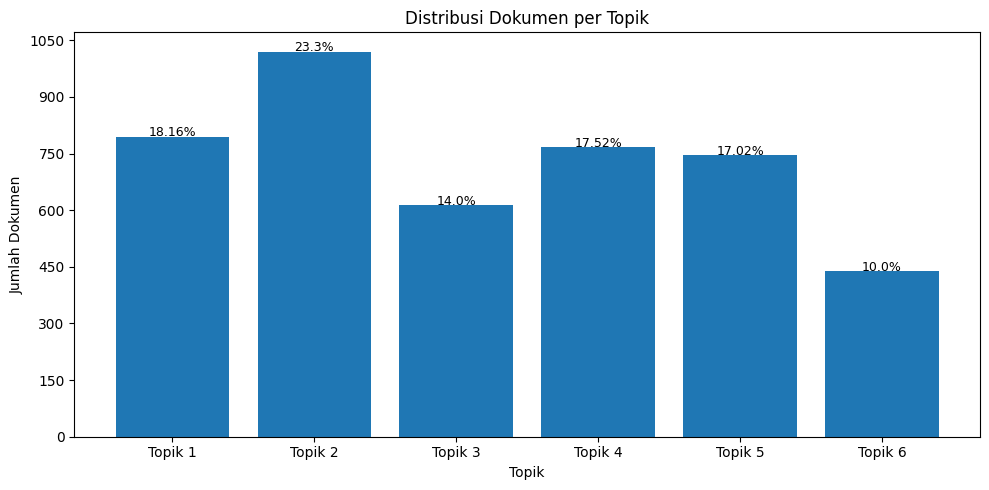

In [17]:
# 17. Visualisasi Distribusi Topik

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    [f'Topik {i}' for i in topic_counts.index],
    topic_counts.values
)

for bar, pct in zip(
    bars,
    topic_percentages.values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{pct}%',
        ha='center',
        fontsize=9
    )

ax.set_xlabel('Topik')
ax.set_ylabel('Jumlah Dokumen')

ax.set_title(
    'Distribusi Dokumen per Topik'
)

ax.yaxis.set_major_locator(
    ticker.MaxNLocator(integer=True)
)

plt.tight_layout()

plt.savefig(
    'lda_topic_distribution.png',
    dpi=300
)

plt.show()

In [18]:
# 18. Simpan Hasil Final
print("Menyimpan hasil akhir...")

cols_to_save = [
    col for col in df_neg.columns
    if col not in ['tokens', 'tokens_lda'] 
]

df_neg[cols_to_save].to_csv(
    'lda_negative_results.csv',
    index=False,
    float_format='%.4f'  
)

print("File berhasil disimpan")

print("File berhasil disimpan")
print("1. lda_topics_keywords.csv")
print("2. lda_negative_results.csv")
print("3. lda_visualization.html")
print("4. lda_coherence_optimization.png")
print("5. lda_topic_distribution.png")

Menyimpan hasil akhir...
File berhasil disimpan
File berhasil disimpan
1. lda_topics_keywords.csv
2. lda_negative_results.csv
3. lda_visualization.html
4. lda_coherence_optimization.png
5. lda_topic_distribution.png


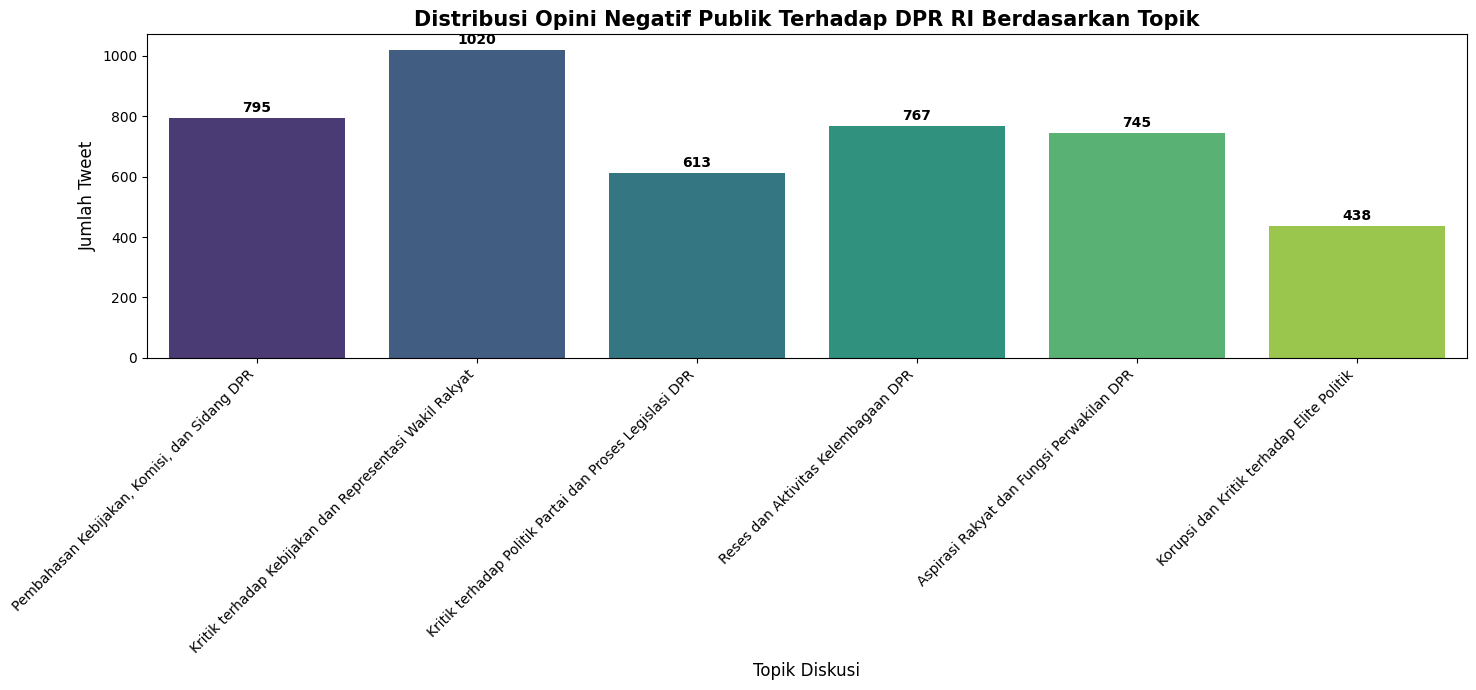

In [ ]:
# 19. Visualisasi Distribusi Topik dengan Nama Topik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data kembali
df_final = pd.read_csv('lda_negative_results.csv')

# 2. Hitung jumlah dokumen per topik
topic_counts = df_final['dominant_topic'].value_counts().sort_index()

# 3. Mapping ID Topik ke Nama Topik (Sesuai interpretasi kita)
topic_labels = {
    1: "Pembahasan Kebijakan, Komisi, dan Sidang DPR",
    2: "Kritik terhadap Kebijakan dan Representasi Wakil Rakyat",
    3: "Kritik terhadap Politik Partai dan Proses Legislasi DPR",
    4: "Reses dan Aktivitas Kelembagaan DPR",
    5: "Aspirasi Rakyat dan Fungsi Perwakilan DPR",
    6: "Korupsi dan Kritik terhadap Elite Politik"
}

topic_counts.index = topic_counts.index.map(topic_labels)

# 4. Plotting
plt.figure(figsize=(15, 7))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette="viridis")

plt.title("Distribusi Opini Negatif Publik Terhadap DPR RI Berdasarkan Topik", fontsize=15, fontweight='bold')
plt.xlabel("Topik Diskusi", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)
plt.xticks(rotation=45, ha="right") # Agar nama topik yang panjang terbaca rapi

# Tambahkan label angka di atas batang
for i, v in enumerate(topic_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

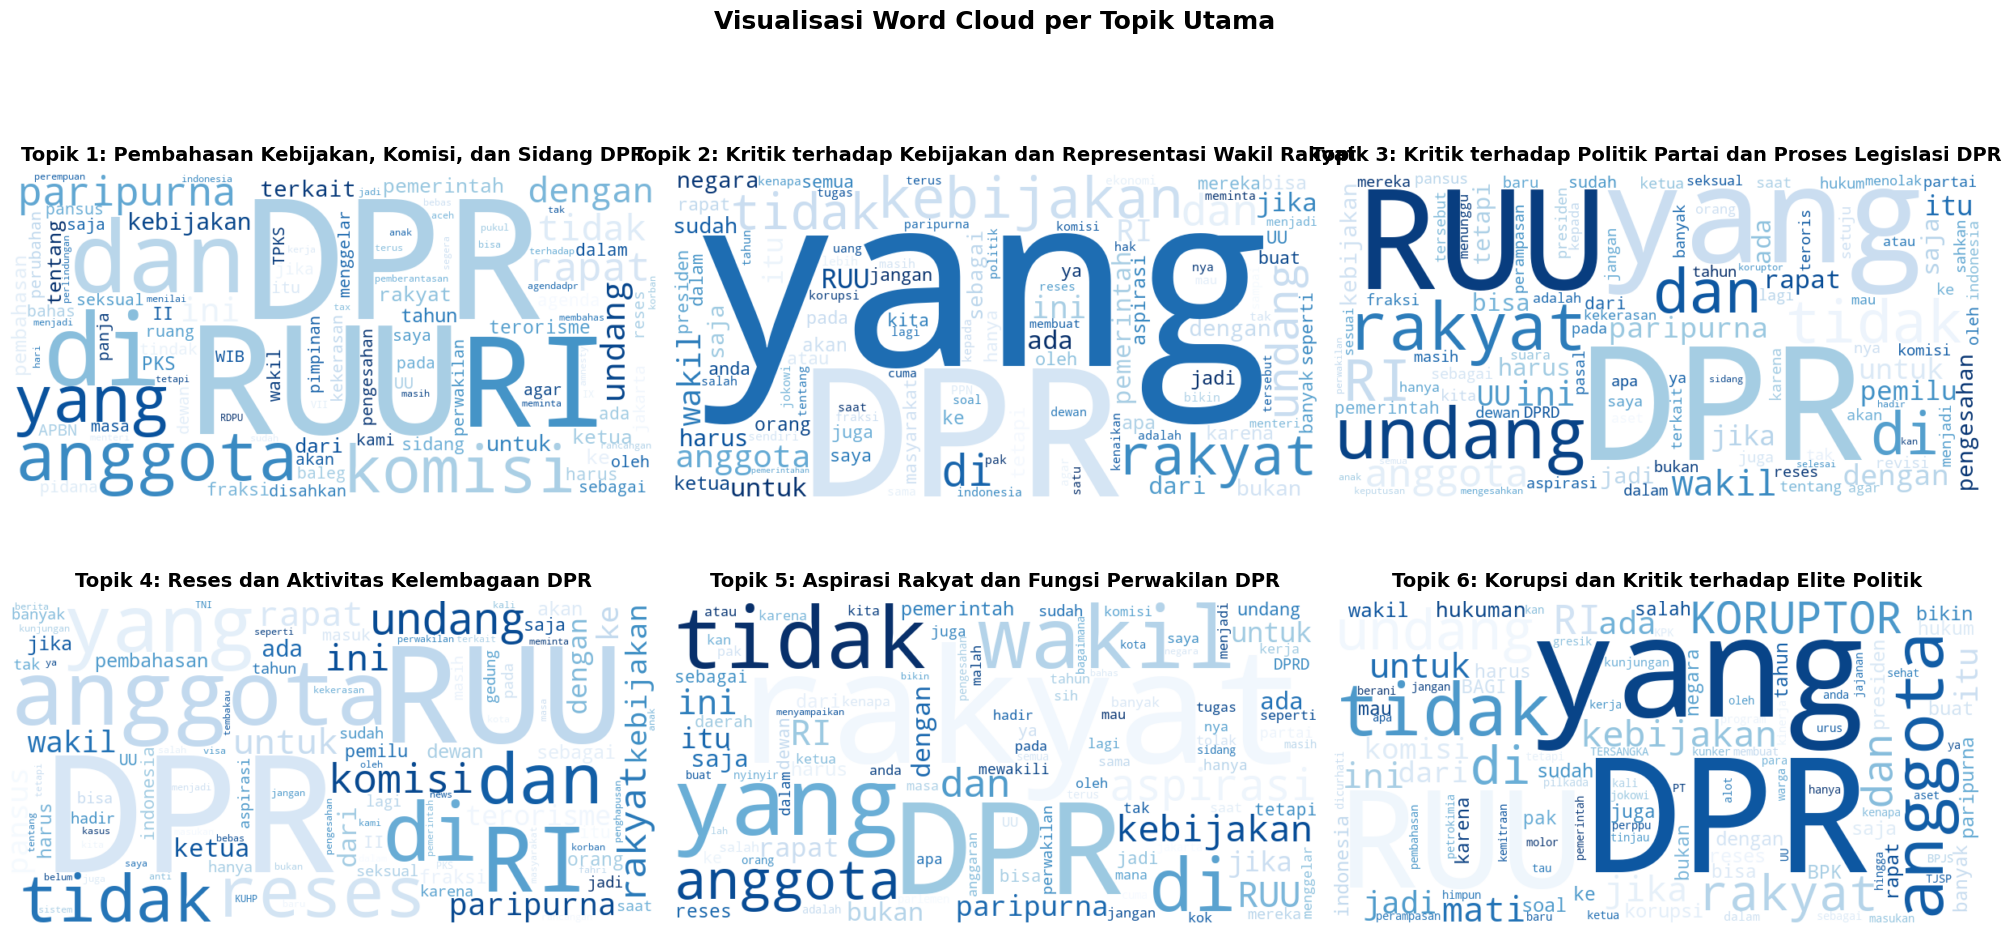

In [ ]:
# 20. Word Cloud untuk Setiap Topik (Versi Fix)

# 1. Install library wordcloud jika belum ada
import sys
import subprocess

try:
    from wordcloud import WordCloud
except ImportError:
    print("Menginstall wordcloud...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    print("wordcloud berhasil diinstall")
    from wordcloud import WordCloud

import matplotlib.pyplot as plt
import pandas as pd

# 2. Load data hasil LDA
# Pastikan file ini ada di folder yang sama
df_final = pd.read_csv('lda_negative_results.csv')

# 3. Setup figure (Grid 2 baris x 3 kolom untuk 6 topik)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

# Judul untuk setiap topik
topic_titles = [
    "Topik 1: Pembahasan Kebijakan, Komisi, dan Sidang DPR",
    "Topik 2: Kritik terhadap Kebijakan dan Representasi Wakil Rakyat",
    "Topik 3: Kritik terhadap Politik Partai dan Proses Legislasi DPR",
    "Topik 4: Reses dan Aktivitas Kelembagaan DPR",
    "Topik 5: Aspirasi Rakyat dan Fungsi Perwakilan DPR",
    "Topik 6: Korupsi dan Kritik terhadap Elite Politik"
]

# 4. Loop membuat Word Cloud untuk tiap topik
for i in range(1, 7):
    # Filter teks hanya untuk topik ini
    texts = df_final[df_final['dominant_topic'] == i]['teks_processed']
    
    # Gabungkan semua teks jadi satu string panjang
    text_combined = " ".join(texts)
    
    # Buat Word Cloud
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        max_words=100, # Ambil 100 kata teratas
        colormap='Blues', # Warna biru profesional
        collocations=False # Hindari kata berulang yang berdampingan
    ).generate(text_combined)
    
    # Plot ke axes
    ax = axes[i-1] # Index mulai dari 0
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(topic_titles[i-1], fontsize=14, fontweight='bold', pad=10)
    ax.axis('off') # Hilangkan koordinat angka

plt.suptitle("Visualisasi Word Cloud per Topik Utama", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

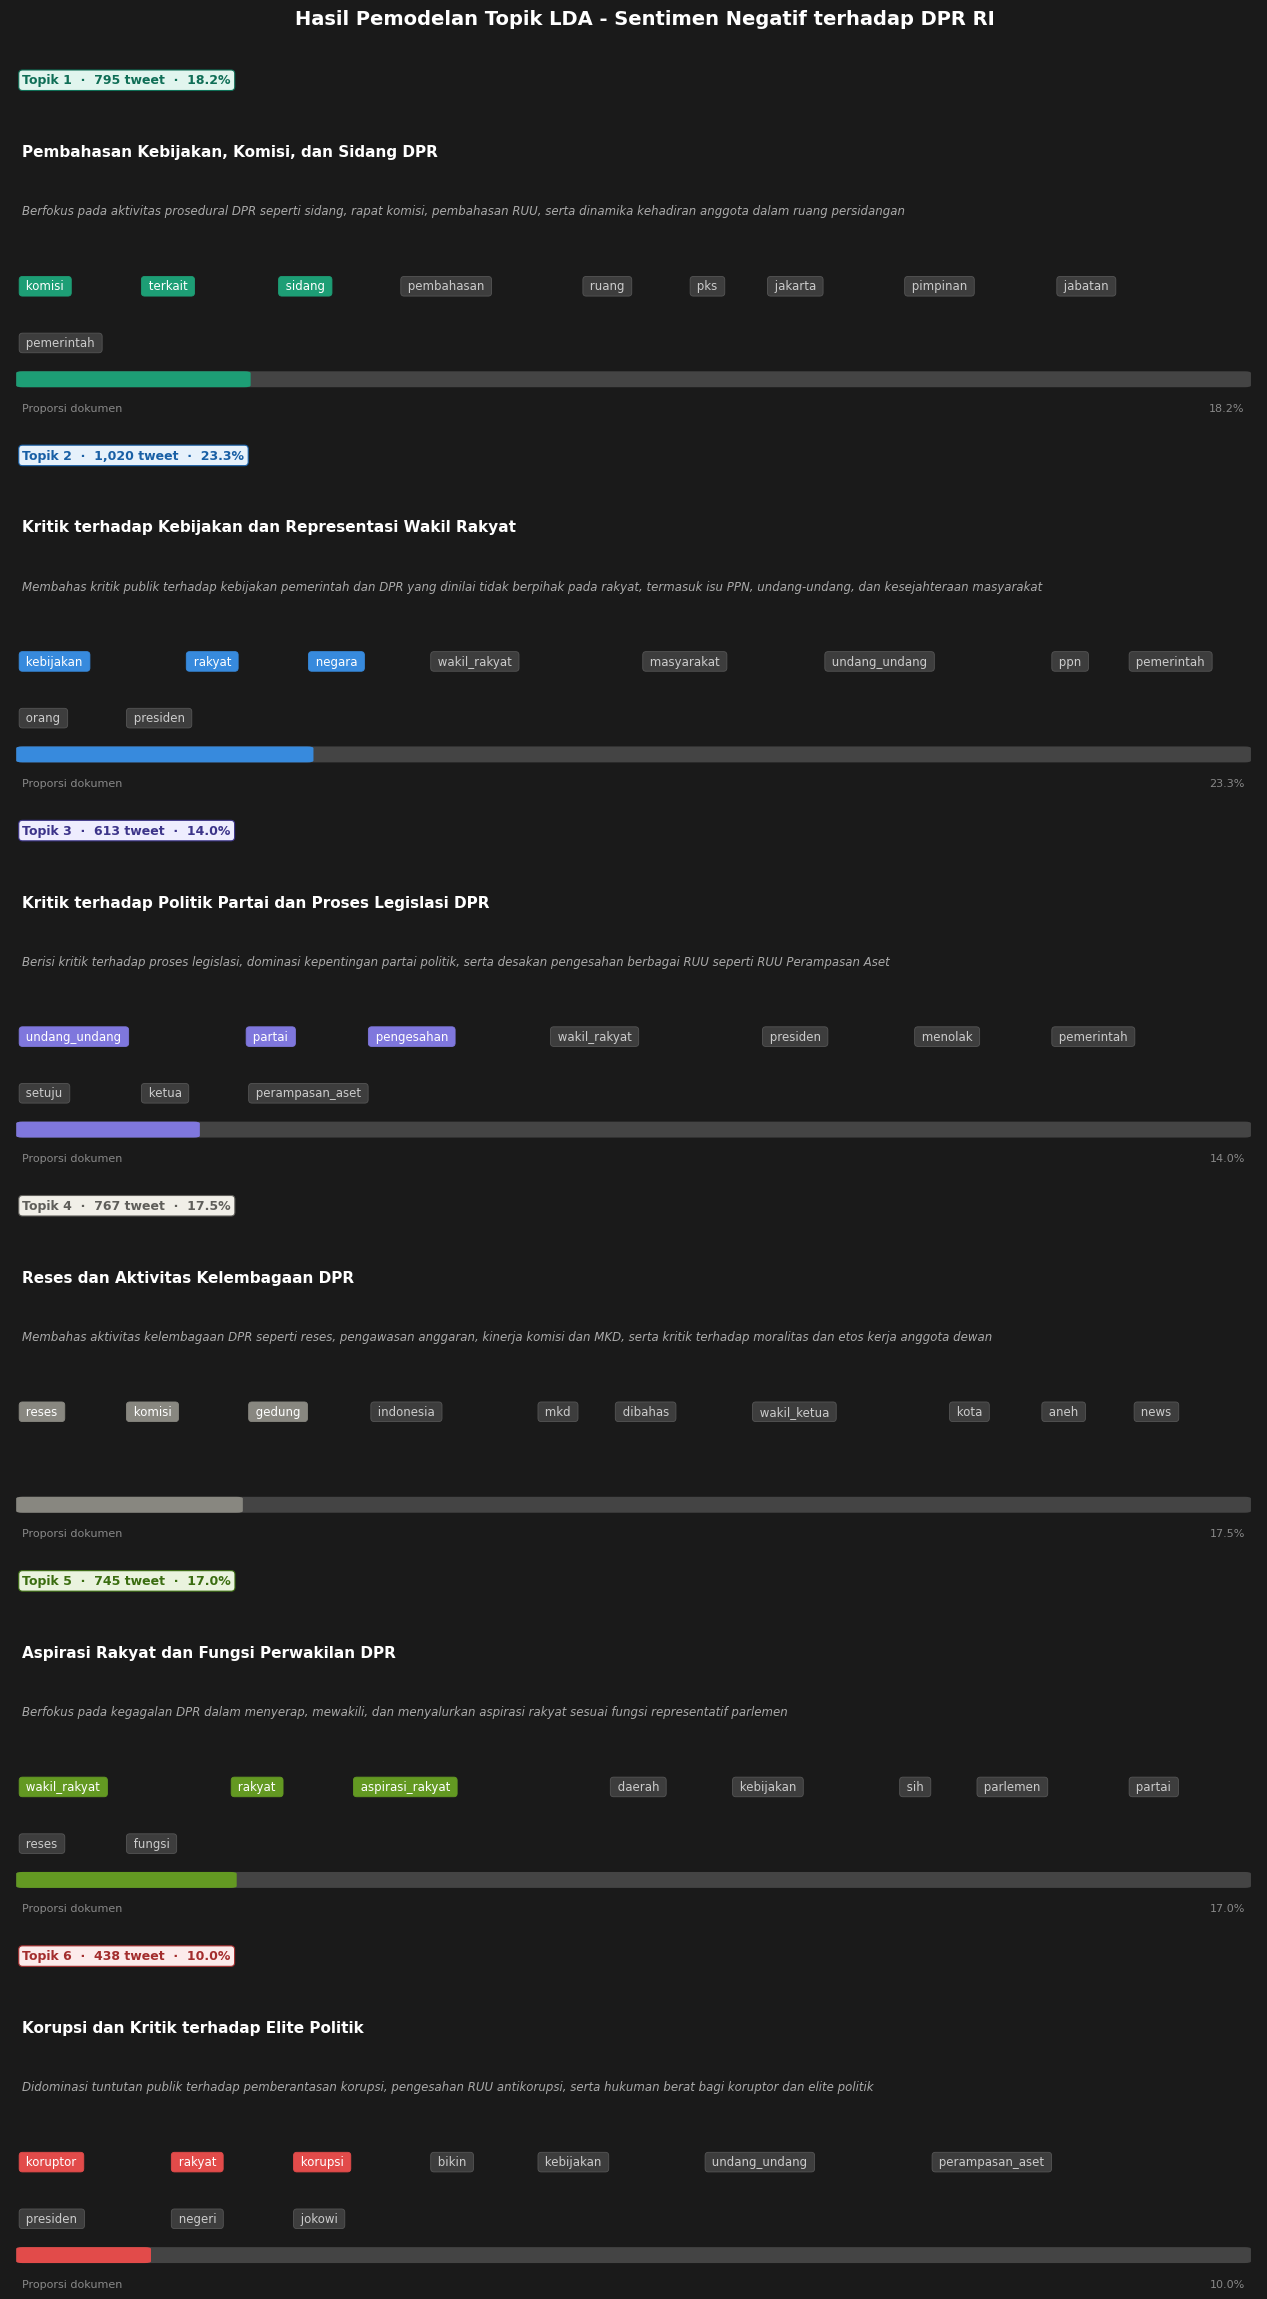

Visualisasi berhasil disimpan: lda_topic_cards.png


In [ ]:
# 21. VISUALISASI KARTU TOPIK LDA

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import re

# 1. Load hasil topik 
df = pd.read_csv('lda_topics_keywords.csv')

# 2. Parser kolom word_probability
def parse_probs(s):
    pairs = re.findall(r"\('([^']+)',\s*np\.float32\(([\d.]+)\)\)", s)
    return [(w, float(p)) for w, p in pairs]

# 3. Label dan metadata topik
topic_labels = {
    1: ("Pembahasan Kebijakan, Komisi, dan Sidang DPR",
    "Berfokus pada aktivitas prosedural DPR seperti sidang, rapat komisi, pembahasan RUU, serta dinamika kehadiran anggota dalam ruang persidangan"),

    2: ("Kritik terhadap Kebijakan dan Representasi Wakil Rakyat",
        "Membahas kritik publik terhadap kebijakan pemerintah dan DPR yang dinilai tidak berpihak pada rakyat, termasuk isu PPN, undang-undang, dan kesejahteraan masyarakat"),

    3: ("Kritik terhadap Politik Partai dan Proses Legislasi DPR",
        "Berisi kritik terhadap proses legislasi, dominasi kepentingan partai politik, serta desakan pengesahan berbagai RUU seperti RUU Perampasan Aset"),

    4: ("Reses dan Aktivitas Kelembagaan DPR",
        "Membahas aktivitas kelembagaan DPR seperti reses, pengawasan anggaran, kinerja komisi dan MKD, serta kritik terhadap moralitas dan etos kerja anggota dewan"),

    5: ("Aspirasi Rakyat dan Fungsi Perwakilan DPR",
        "Berfokus pada kegagalan DPR dalam menyerap, mewakili, dan menyalurkan aspirasi rakyat sesuai fungsi representatif parlemen"),

    6: ("Korupsi dan Kritik terhadap Elite Politik",
        "Didominasi tuntutan publik terhadap pemberantasan korupsi, pengesahan RUU antikorupsi, serta hukuman berat bagi koruptor dan elite politik"),
}

# Jumlah dokumen per topik
doc_counts = {1: 795, 2: 1020, 3: 613, 4: 767, 5: 745, 6: 438}
total = sum(doc_counts.values())

# 4. Skema warna per topik 
colors   = ['#1D9E75', '#378ADD', '#7F77DD', '#888780', '#639922', '#E24B4A']
badge_bg = ['#E1F5EE', '#E6F1FB', '#EEEDFE', '#F1EFE8', '#EAF3DE', '#FCEBEB']
badge_fg = ['#0F6E56', '#185FA5', '#3C3489', '#5F5E5A', '#3B6D11', '#A32D2D']

# 5. Render kartu
fig, axes = plt.subplots(6, 1, figsize=(13, 23))
fig.patch.set_facecolor('#1a1a1a')
plt.subplots_adjust(hspace=0.55)

for ax, (_, row) in zip(axes, df.iterrows()):
    tid   = int(row['topic_id'])
    pairs = parse_probs(row['word_probability'])
    words = [w for w, _ in pairs]
    top3  = set(words[:3])
    count = doc_counts[tid]
    pct   = count / total * 100
    label, sublabel = topic_labels[tid]
    col   = colors[tid - 1]
    bb    = badge_bg[tid - 1]
    bf    = badge_fg[tid - 1]

    ax.set_facecolor('#2a2a2a')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(0.5)

    # Badge topik
    ax.text(0.01, 0.95,
            f"Topik {tid}  ·  {count:,} tweet  ·  {pct:.1f}%",
            transform=ax.transAxes, fontsize=9, fontweight='bold',
            color=bf, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=bb,
                      edgecolor=bf, linewidth=0.8))

    # Judul topik
    ax.text(0.01, 0.75, label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='white', va='top')

    # Subjudul / deskripsi
    ax.text(0.01, 0.58, sublabel, transform=ax.transAxes,
            fontsize=8.5, color='#aaaaaa', va='top', style='italic')

    # Chip kata kunci (3 kata teratas berwarna, sisanya abu)
    x, y_chip = 0.01, 0.35
    for w in words:
        is_top = w in top3
        fc = col      if is_top else '#3d3d3d'
        tc = 'white'  if is_top else '#cccccc'
        ec = col      if is_top else '#555'
        ax.text(x, y_chip, f" {w} ", transform=ax.transAxes,
                fontsize=8.5, color=tc, va='center',
                bbox=dict(boxstyle='round,pad=0.28', facecolor=fc,
                          edgecolor=ec, linewidth=0.6))
        x += len(w) * 0.012 + 0.026
        if x > 0.91:           # wrap ke baris berikutnya
            x, y_chip = 0.01, y_chip - 0.16

    # Progress bar — background
    ax.add_patch(FancyBboxPatch(
        (0.01, 0.07), 0.98, 0.035,
        boxstyle='round,pad=0.005', transform=ax.transAxes,
        facecolor='#444', edgecolor='none', clip_on=False))
    # Progress bar — isian proporsi
    ax.add_patch(FancyBboxPatch(
        (0.01, 0.07), 0.98 * (pct / 100), 0.035,
        boxstyle='round,pad=0.005', transform=ax.transAxes,
        facecolor=col, edgecolor='none', clip_on=False))

    ax.text(0.01, 0.02, "Proporsi dokumen", transform=ax.transAxes,
            fontsize=8, color='#888', va='top')
    ax.text(0.99, 0.02, f"{pct:.1f}%", transform=ax.transAxes,
            fontsize=8, color='#888', va='top', ha='right')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

fig.suptitle(
    "Hasil Pemodelan Topik LDA - Sentimen Negatif terhadap DPR RI",
    fontsize=14, fontweight='bold', color='white', y=0.999)

plt.tight_layout()
plt.savefig('lda_topic_cards.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
print("Visualisasi berhasil disimpan: lda_topic_cards.png")

(Sedikit Catatan)

| Tahap | Cell | Input -> Output | Parameter Utama | Tujuan |
|---|---|---|---|---|
| **1. Filter Sentimen** | Cell 4 | `sentiment_clean.csv` -> 4.854 tweet negatif | - | Mengambil hanya data negatif untuk fokus penelitian |
| **2. Preprocessing LDA** | Cell 5 | 4.854 -> 4.378 dokumen valid | `len(tokens) >= 5` | Membuang tweet terlalu pendek yang tidak informatif untuk LDA |
| **3. Bigram/Trigram dan Corpus** | Cell 6-7 | 4.378 dokumen -> 1.821 kata unik (*vocabulary*) | `no_below=5`, `no_above=0.5` | Menyeragamkan frasa dan menyaring kata yang terlalu jarang maupun terlalu umum |
| **4. Grid Search Jumlah Topik** | Cell 8 | Uji `k = [2,3,4,5,6,7]` -> Pilih `k=6` | `passes=5`, `iterations=50` | Mencari jumlah topik optimal menggunakan *Coherence Score* |
| **5. Uji Stabilitas Topik** | Cell 10-11 | Training ulang `k=6` dengan `passes=1,2,3,4,5` | `iterations=100` | Memastikan kata kunci topik tetap stabil dan tidak berubah secara acak pada setiap *pass* |
| **6. Training Model Final** | Cell 12 | Model terbaik -> LDA Final | `passes=15`, `iterations=100` | Memaksimalkan konvergensi model untuk hasil akhir dan interpretasi topik |

## Ringkasan Output

| File | Deskripsi |
|---|---|
| `lda_coherence_optimization.png` | Grafik coherence score per jumlah topik |
| `lda_topics_keywords.csv` | Kata kunci top-10 per topik |
| `lda_visualization.html` | Visualisasi interaktif pyLDAvis |
| `lda_negative_results.csv` | Data negatif dan label topik dominan |
| `lda_topic_distribution.png` | Grafik distribusi dokumen per topik |